## **What is the most optimal skill to learn for Data Analysts?**

**Methodology**

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [ ]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

# Loading data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# cuz this date column was type str, now changed to type datetime

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
# converting string formatted list to actual list

In [5]:
df_us_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_us_da = df_us_da.dropna(subset = 'salary_year_avg')
df_us_da_exploded = df_us_da.explode('job_skills')

In [6]:
df_us_da_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [8]:
df_us_da_skills = df_us_da_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('count', ascending = False)

In [10]:
df_us_da_skills = df_us_da_skills.rename(columns = {'count': 'skill_count', 'median': 'median_salary'})

In [11]:
df_job_count = len(df_us_da)

df_us_da_skills['skill_percent'] = df_us_da_skills['skill_count'] / df_job_count * 100

In [12]:
df_us_da_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [14]:
skill_percent = 5

df_skills_high = df_us_da_skills[df_us_da_skills['skill_percent'] > skill_percent]
df_skills_high

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


([Text(58.85662201262184, 91267.64462737128, 'sql'),
  Text(43.7203665341562, 84659.64462737128, 'excel'),
  Text(35.79095303040717, 97814.21129093904, 'python'),
  Text(34.52377987235623, 93189.21129093906, 'tableau'),
  Text(22.652639956871738, 89818.56635502819, 'sas'),
  Text(20.889170511832535, 92752.00871803853, 'r'),
  Text(23.032550648782095, 90869.09280240732, 'power bi'),
  Text(15.208042668882143, 85407.34461807463, 'powerpoint'),
  Text(12.604668092923294, 81462.39462737126, 'word'),
  Text(10.561340857973526, 92814.21129093906, 'sql server'),
  Text(8.974806499376655, 97237.96129093907, 'oracle'),
  Text(6.230729926302189, 90252.00871803855, 'go')],
 [<matplotlib.patches.FancyArrowPatch at 0x1eb003ebb30>])

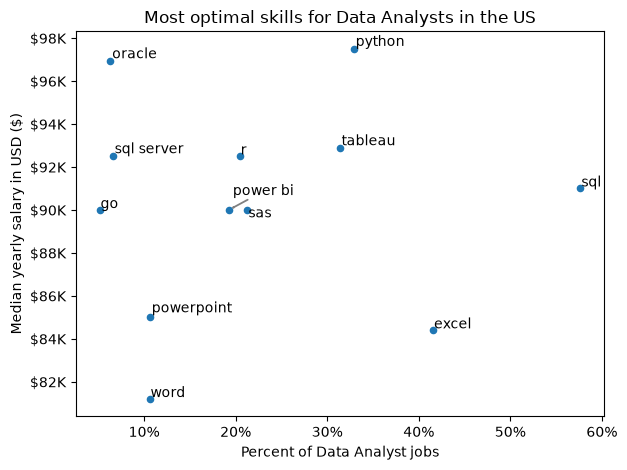

In [22]:
from adjustText import adjust_text

df_skills_high.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary')
plt.title('Most optimal skills for Data Analysts in the US')
plt.xlabel('Percent of Data Analyst jobs')
plt.ylabel('Median yearly salary in USD ($)')
plt.tight_layout()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

texts = []
for i, txt in enumerate(df_skills_high.index):
    texts.append(plt.text(df_skills_high['skill_percent'].iloc[i], df_skills_high['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray', lw= 1.3))

In [26]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value
                
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))



In [27]:
technology_dict

{'analyst_tools': ['spreadsheet',
  'esquisse',
  'powerpoint',
  'datarobot',
  'outlook',
  'power bi',
  'excel',
  'sharepoint',
  'ssis',
  'visio',
  'sap',
  'cognos',
  'ssrs',
  'sas',
  'sheets',
  'dax',
  'word',
  'nuix',
  'alteryx',
  'tableau',
  'microstrategy',
  'ms access',
  'splunk',
  'looker',
  'spss',
  'qlik',
  'powerbi',
  'msaccess'],
 'programming': ['rust',
  'apl',
  'ruby',
  'haskell',
  'typescript',
  'golang',
  'css',
  'cobol',
  'r',
  'sass',
  'clojure',
  'lisp',
  'f#',
  'java',
  'sql',
  'php',
  'scala',
  'vba',
  'vb.net',
  't-sql',
  'ocaml',
  'c#',
  'fortran',
  'delphi',
  'javascript',
  'nosql',
  'sas',
  'lua',
  'c',
  'visual basic',
  'dart',
  'assembly',
  'pascal',
  'kotlin',
  'python',
  'elixir',
  'c++',
  'shell',
  'mongodb',
  'go',
  'powershell',
  'swift',
  'crystal',
  'erlang',
  'html',
  'perl',
  'visualbasic',
  'no-sql',
  'bash',
  'groovy',
  'julia',
  'objective-c',
  'mongo',
  'solidity',
  'mat

In [32]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns = ['technology', 'skills'])

In [33]:
df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,spreadsheet
0,analyst_tools,esquisse
0,analyst_tools,powerpoint
0,analyst_tools,datarobot
0,analyst_tools,outlook
...,...,...
9,sync,mattermost
9,sync,microsoft teams
9,sync,google chat
9,sync,rocketchat


In [34]:
df_skills_high

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [36]:
df_plot = df_skills_high.merge(df_technology, left_on = 'job_skills', right_on = 'skills')

([Text(58.96501096380593, 91304.01563099655, 'sql'),
  Text(43.855435853327045, 84836.98710547524, 'excel'),
  Text(35.84368846166679, 97851.00612248946, 'python'),
  Text(34.521765001611456, 93226.00612248945, 'tableau'),
  Text(23.088384328106713, 89888.45876824016, 'sas'),
  Text(20.888941233437443, 92804.01563099655, 'r'),
  Text(22.8118472223767, 90969.24007257687, 'power bi'),
  Text(15.368854398968908, 85397.99661398235, 'powerpoint'),
  Text(12.671612186945596, 81498.76563099655, 'word'),
  Text(10.886264537470383, 92851.00612248945, 'sql server'),
  Text(9.027680887239365, 97274.75612248946, 'oracle'),
  Text(6.230042091116903, 90304.01563099655, 'go')],
  <matplotlib.patches.FancyArrowPatch at 0x1eafd03a900>])

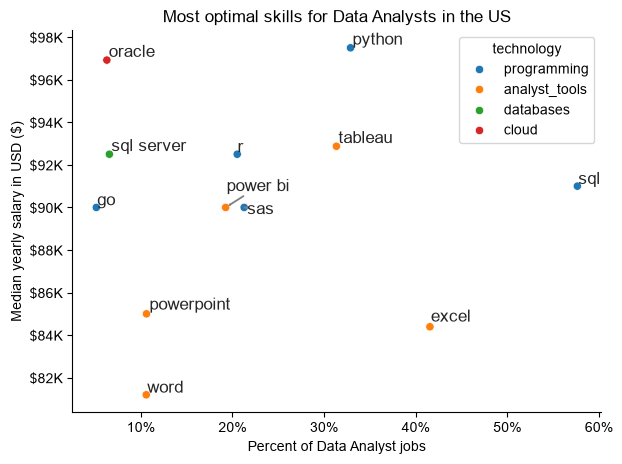

In [41]:
from adjustText import adjust_text

# df_plot.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary')
sns.scatterplot(
    data = df_plot,
    x= 'skill_percent',
    y= 'median_salary',
    hue = 'technology'
)

sns.set_theme(style= 'ticks')
sns.despine()

plt.title('Most optimal skills for Data Analysts in the US')
plt.xlabel('Percent of Data Analyst jobs')
plt.ylabel('Median yearly salary in USD ($)')
plt.tight_layout()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

texts = []
for i, txt in enumerate(df_skills_high.index):
    texts.append(plt.text(df_skills_high['skill_percent'].iloc[i], df_skills_high['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray', lw= 1.3))